In [112]:
import sys
sys.path.append('../code')

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import make_network, set_train_parameters, simulate, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse, get_prior_dict
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

import intrinsic_prior_configurations as prior_config


config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [113]:
key_order = ["cue_ampa_gS", "context_ampa_gS",
                "IE_gaba_gS", "II_gaba_gS", "EI_ampa_gS", "EE_ampa_gS",
                "cue_dend_ampa_gS", "context_dend_ampa_gS",
                "IE_dend_gaba_gS", "EE_dend_ampa_gS",
                "cue_ampa_pconn", "context_ampa_pconn",
                "IE_gaba_pconn", "II_gaba_pconn", "EI_ampa_pconn", "EE_ampa_pconn",
                "cue_dend_ampa_pconn", "context_dend_ampa_pconn",
                "IE_dend_gaba_pconn", "EE_dend_ampa_pconn",
                "E_Leak_gLeak", "E_dend_Leak_gLeak", "I_Leak_gLeak",
                "E_Km_gKm", "E_CaL_gCaL", "E_CaT_gCaT", "I_Km_gKm", "I_CaL_gCaL", "I_CaT_gCaT",
                "E_dend_Km_gKm", "E_dend_CaL_gCaL", "E_dend_CaT_gCaT",]

label_dict = {
"cue_ampa_gS": "Cue",
"context_ampa_gS": "Context",
"IE_gaba_gS": "I$\\rightarrow$E$_{\\rm{s}}$",
"II_gaba_gS": "I$\\rightarrow$I",
"EI_ampa_gS": "E$\\rightarrow$I",
"EE_ampa_gS": "E$\\rightarrow$E$_{\\rm{s}}$",
"cue_dend_ampa_gS": "Cue",
"context_dend_ampa_gS": "Context",
"IE_dend_gaba_gS": "I$\\rightarrow$E$_{\\rm{d}}$",
"EE_dend_ampa_gS": "E$\\rightarrow$E$_{\\rm{d}}$",
"cue_ampa_pconn": "Cue",
"context_ampa_pconn": "Context",
"IE_gaba_pconn": "I$\\rightarrow$E$_{\\rm{s}}$",
"II_gaba_pconn": "I$\\rightarrow$I",
"EI_ampa_pconn": "E$\\rightarrow$I",
"EE_ampa_pconn": "E$\\rightarrow$E$_{\\rm{s}}$",
"cue_dend_ampa_pconn": "Cue",
"context_dend_ampa_pconn": "Context",
"IE_dend_gaba_pconn": "I$\\rightarrow$E$_{\\rm{d}}$",
"EE_dend_ampa_pconn": "E$\\rightarrow$E$_{\\rm{d}}$",
"E_Leak_gLeak": "E$_{\\rm{s}}$ Leak",
"E_dend_Leak_gLeak": "E$_{\\rm{d}}$ Leak",
"I_Leak_gLeak": "I Leak",
"E_Km_gKm": "E$_{\\rm{s }}$ Km",
"E_CaL_gCaL": "E$_{\\rm{s}}$ CaL",
"E_CaT_gCaT": "E$_{\\rm{s}}$ CaT",
"I_Km_gKm": "I Km",
"I_CaL_gCaL": "I CaL",
"I_CaT_gCaT": "I CaT",
"E_dend_Km_gKm": "E$_{\\rm{d}}$ Km",
"E_dend_CaL_gCaL": "E$_{\\rm{d}}$ CaL",
"E_dend_CaT_gCaT": "E$_{\\rm{d}}$ CaT"}

param_names = list(label_dict.keys())
label_names = list(label_dict.values())

In [136]:
save_path = '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations'

config_list = [
    ('Esoma_Isoma', prior_config.update_prior_dict_Esoma_Isoma), # 0
    ('Edend_Idend', prior_config.update_prior_dict_Edend_Idend), # 1
    ('Esoma_Idend', prior_config.update_prior_dict_Esoma_Idend), # 2
    ('Edend_Isoma', prior_config.update_prior_dict_Edend_Isoma), # 3
    ('Esoma_Isomadend', prior_config.update_prior_dict_Esoma_Isomadend), # 4
    # ('Edend_Isomadend', prior_config.update_prior_dict_Edend_Isomadend), # 5
    # ('Esomadend_Isoma', prior_config.update_prior_dict_Esomadend_Isoma), # 6
    # ('Esomadend_Idend', prior_config.update_prior_dict_Esomadend_Idend), # 7
    # ('Esomadend_Isomadend', prior_config.update_prior_dict_Esomadend_Isomadend)
    ] # 8

In [137]:
def get_opt_data(data_path):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()

    num_flows = 10
    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')

        # error_mask = error < 3.0
        # theta_list.append(theta[error_mask])
        # error_list.append(error[error_mask])

        theta_list.append(theta)
        error_list.append(error)


    error_sort = np.argsort(error)

    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'error_sort': error_sort, 
                }

    return res_dict

In [138]:
res_dict = dict()
for name, _ in config_list:
    data_path = f'{save_path}/{name}'
    res_dict[name] = get_opt_data(data_path)

Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Esoma_Isoma
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9
Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Edend_Idend
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9
Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Esoma_Idend
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9
Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Edend_Isoma
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9
Loading data from: /users/ntolley/data/ntolley/dendractor/intrinsic_permutations/Esoma_Isomadend
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9


In [139]:
conn_strength_list = ["IE_gaba_gS", "II_gaba_gS", "EI_ampa_gS", "EE_ampa_gS", "IE_dend_gaba_gS", "EE_dend_ampa_gS"]

conn_prob_list = ["IE_gaba_pconn", "II_gaba_pconn", "EI_ampa_pconn", "EE_ampa_pconn", "IE_dend_gaba_pconn", "EE_dend_ampa_pconn"]

  
biophysics_list = ["E_Leak_gLeak", "E_Km_gKm", "E_CaL_gCaL", "E_CaT_gCaT",
                   "E_dend_Leak_gLeak", "E_dend_Km_gKm","E_dend_CaL_gCaL", "E_dend_CaT_gCaT",
                   "I_Leak_gLeak", "I_Km_gKm", "I_CaL_gCaL", "I_CaT_gCaT"]

extrinsic_input_list = ["cue_ampa_pconn", "context_ampa_pconn"]

In [140]:
color_dict = {
        'Edend_Isoma': 'C0', 'Edend_Idend': 'slateblue', 'Edend_Isomadend': 'lightsteelblue',
        'Esoma_Isoma': 'C3', 'Esoma_Idend': 'darkorange', 'Esoma_Isomadend': 'rosybrown',
        'Esomadend_Isoma': 'C2', 'Esomadend_Idend': 'palegreen', 'Esomadend_Isomadend': 'darkseagreen'}

legend_dict = {
        'Edend_Idend': '$\\rm{E_{d} \\ I_{d}}$', 'Edend_Isoma': '$\\rm{E_{d} \\ I_{s}}$', 'Edend_Isomadend': '$\\rm{E_{d} \\ I_{sd}}$',
        'Esoma_Idend': '$\\rm{E_{s} \\ I_{d}}$', 'Esoma_Isoma': '$\\rm{E_{s} \\ I_{s}}$', 'Esoma_Isomadend': '$\\rm{E_{s} \\ I_{sd}}$',
        'Esomadend_Idend': '$\\rm{E_{sd} \\ I_{d}}$', 'Esomadend_Isoma': '$\\rm{E_{sd} \\ I_{s}}$', 'Esomadend_Isomadend': '$\\rm{E_{sd} \\ I_{sd}}$'}


# plot_groups = [
#         ['Esoma_Isoma', 'Esoma_Idend', 'Esoma_Isomadend'],
#         ['Edend_Isoma', 'Edend_Idend', 'Edend_Isomadend'],
#         ['Esomadend_Isoma', 'Esomadend_Idend', 'Esomadend_Isomadend']]

plot_groups = [
        ['Esoma_Isoma', 'Esoma_Idend', 'Esoma_Isomadend'],
        ['Edend_Isoma', 'Edend_Idend']
        ]

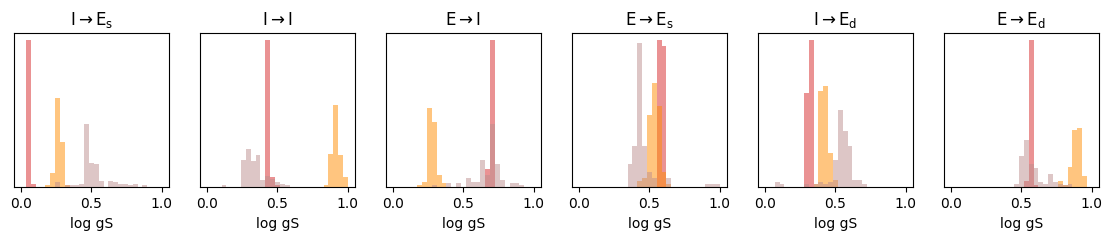

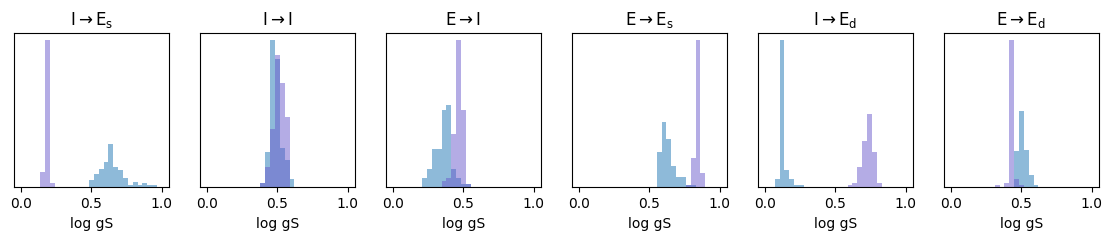

In [145]:
flow_idx = 9
# name1, name2 = 'Esomadend_Isomadend', 'Esoma_Isoma'
# name1, name2 = 'Esoma_Isoma', 'Edend_Idend'
# name1, name2 = 'Edend_Isoma', 'Edend_Idend'

bins = np.linspace(0, 1, 30)
for group in plot_groups:
    plt.figure(figsize=(14,2))
    for idx, name in enumerate(conn_strength_list):
        plt.subplot(1,6,idx+1)
        theta_idx = np.where(np.array(param_names) == name)[0].squeeze()
        plot_title = label_names[theta_idx]
        for name in group:
            plt.hist(res_dict[name]['theta_list'][flow_idx][:, theta_idx], bins=bins, density=True, label=name1, color=color_dict[name], alpha=0.5)
        plt.title(plot_title)
        plt.xlabel('log gS')
        # plt.ylim(0, 24)
        plt.yticks([])
    

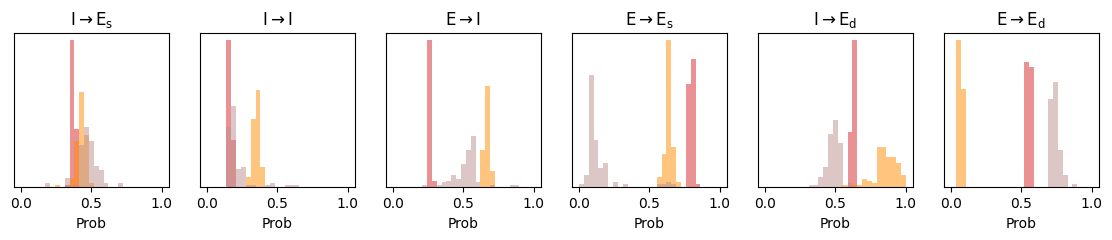

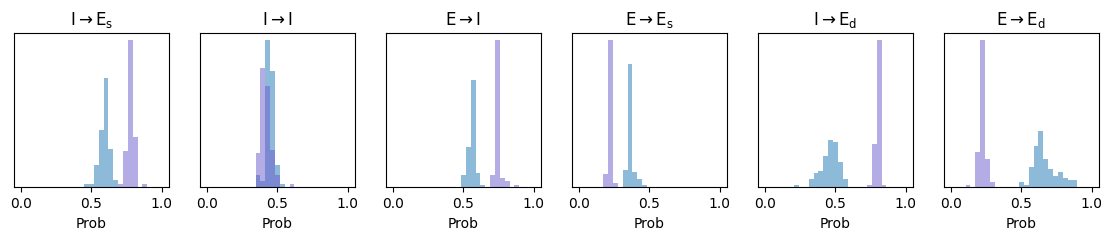

In [146]:
bins = np.linspace(0, 1, 30)
for group in plot_groups:
    plt.figure(figsize=(14,2))
    for idx, name in enumerate(conn_prob_list):
        plt.subplot(1,6,idx+1)
        theta_idx = np.where(np.array(param_names) == name)[0].squeeze()
        plot_title = label_names[theta_idx]
        for name in group:
            plt.hist(res_dict[name]['theta_list'][flow_idx][:, theta_idx], bins=bins, density=True, label=name, color=color_dict[name], alpha=0.5)
        plt.title(plot_title)
        plt.xlabel('Prob')
        # plt.ylim(0, 35)
        plt.yticks([])
    

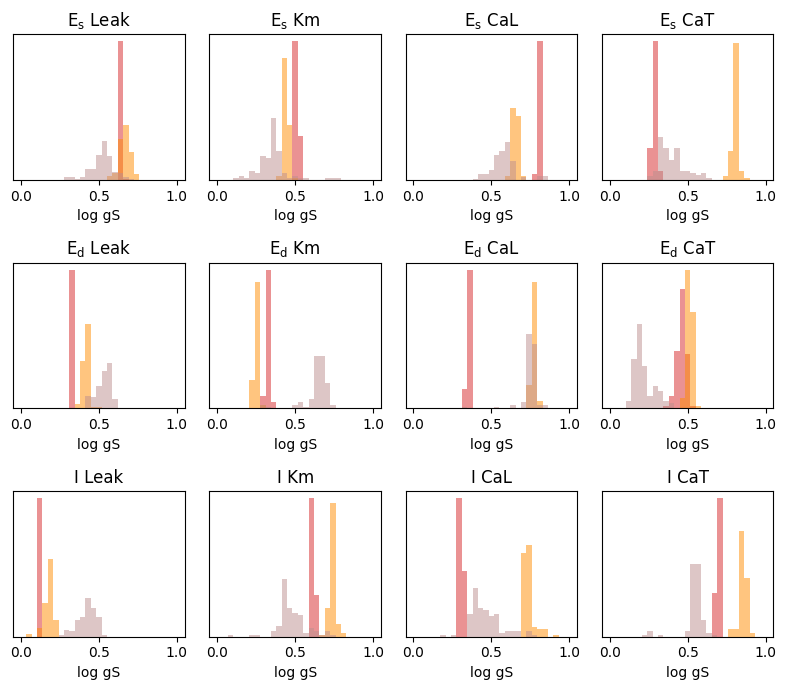

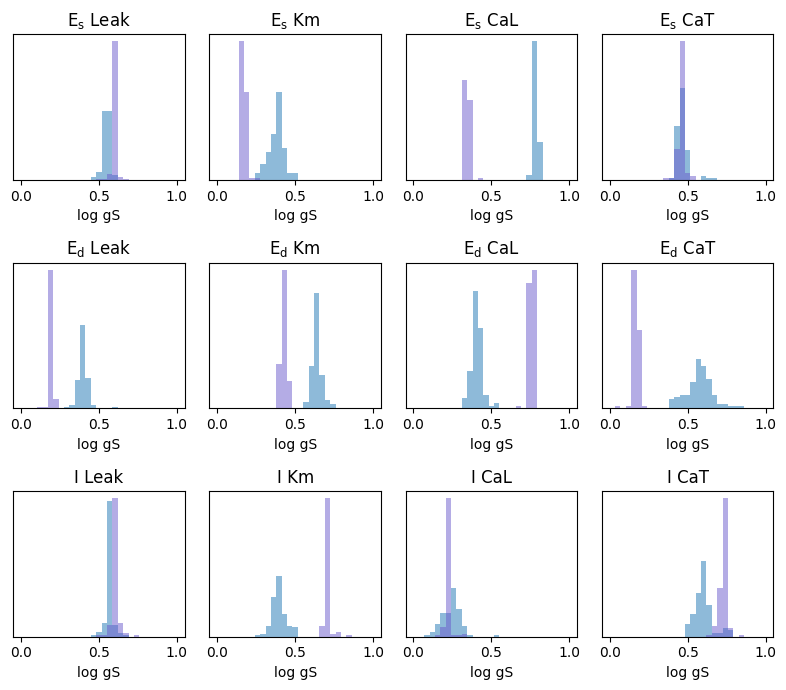

In [147]:
bins = np.linspace(0, 1, 30)

for group in plot_groups:

    plt.figure(figsize=(8,7))
    for idx, name in enumerate(biophysics_list):
        plt.subplot(3,4,idx+1)
        theta_idx = np.where(np.array(param_names) == name)[0].squeeze()
        plot_title = label_names[theta_idx]
        for name in group:
            plt.hist(res_dict[name]['theta_list'][flow_idx][:, theta_idx], bins=bins, density=True, label=name, color=color_dict[name], alpha=0.5)
        plt.title(plot_title)
        plt.xlabel('log gS')
        # plt.ylim(0, 35)
        plt.yticks([])
    plt.tight_layout()
    

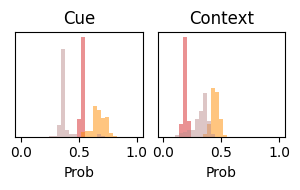

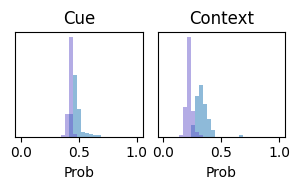

In [148]:
bins = np.linspace(0, 1, 30)

for group in plot_groups:
    plt.figure(figsize=(3,2))
    for idx, name in enumerate(extrinsic_input_list):
        plt.subplot(1,2,idx+1)
        theta_idx = np.where(np.array(param_names) == name)[0].squeeze()
        plot_title = label_names[theta_idx]
        for name in group:
            plt.hist(res_dict[name]['theta_list'][flow_idx][:, theta_idx], bins=bins, density=True, label=name, color=color_dict[name], alpha=0.5)
        plt.title(plot_title)
        plt.xlabel('Prob')
        # plt.ylim(0, 35)
        plt.yticks([])
    plt.tight_layout()
    